# COVID-19 IMPACT ON PARCEL BUSINESS


# Data Loading

## In this step, we import the required libraries and load the dataset into a pandas DataFrame for analysis.

import pandas as pd
import matplotlib.pyplot as plt



df = pd.read_csv("Downloads/COVID_Parcel_Business.csv")


df.head()

# Data Cleaning

## In this step, column names are cleaned by removing extra spaces, converting them to lowercase, and replacing spaces with underscores for easier analysis.

In [38]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()


,fakecustomerid,the_year,the_week,volume
0,718117,2021,1,8
1,718117,2020,7,257
2,718117,2019,39,141
3,718117,2018,1,14
4,718117,2021,2,192


# Checking Column Names

## This helps verify that column names have been cleaned and formatted correctly.

In [39]:
df.columns

Index(['fakecustomerid', 'the_year', 'the_week', 'volume'], dtype='object')

# Data Preparation and Aggregation

## In this step, column names are cleaned for consistency, and the data is grouped by year and week to calculate total parcel volume for each week.

In [40]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [22]:
weekly = df.groupby(['the_year', 'the_week'])['volume'].sum().reset_index()
weekly.head()

,the_year,the_week,volume
0,2018,1,817751
1,2018,2,925839
2,2018,3,854760
3,2018,4,800040
4,2018,5,812249


## Weekly Parcel Trend Visualization

In this step, the data is filtered to include only the years 2019 and 2020. A line chart is created to compare weekly parcel volumes between these two years.

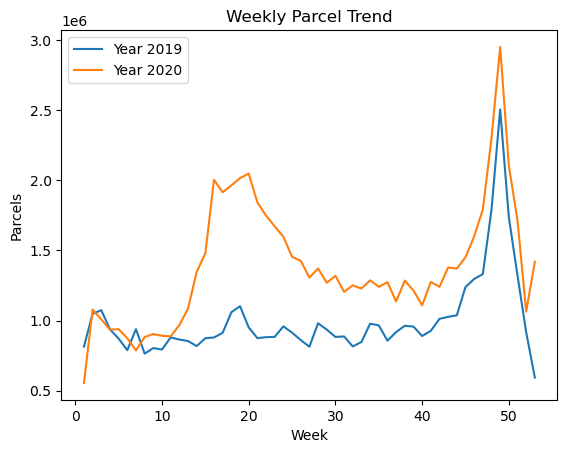

In [29]:
import matplotlib.pyplot as plt

# Filter first
weekly = weekly[weekly['the_year'].isin([2019, 2020])]

# Then plot
for y in weekly['the_year'].unique():
    temp = weekly[weekly['the_year'] == y]
    plt.plot(temp['the_week'], temp['volume'], label=f"Year {y}")

plt.legend()
plt.xlabel("Week")
plt.ylabel("Parcels")
plt.title("Weekly Parcel Trend")
plt.show()

# Industry Standard Growth Rate (ISGR)

## In this step, the Industry Standard Growth Rate (ISGR) is calculated by comparing parcel volumes from week 1 to week 15 in 2019 and 2020. This helps establish a baseline growth rate before the impact of COVID-19.

In [31]:
vol_2020 = df[(df['year'] == 2020) & (df['week'] <= 15)]['parcels'].sum()
vol_2019 = df[(df['year'] == 2019) & (df['week'] <= 15)]['parcels'].sum()

isgr = (vol_2020 - vol_2019) / vol_2019
print("ISGR:", isgr)

ISGR: 0.11401523880240338


# Customer-Level Aggregation

## In this step, total parcel volumes are calculated for each customer separately for the years 2019 and 2020. The results are combined into a single dataset for comparison.

In [32]:
cust_2019 = df[df['year'] == 2019].groupby('customer_id')['parcels'].sum()
cust_2020 = df[df['year'] == 2020].groupby('customer_id')['parcels'].sum()

cust = pd.DataFrame({
    '2019': cust_2019,
    '2020': cust_2020
}).fillna(0)

cust.head()

,2019,2020
customer_id,,
100771,1816,1789.0
102180,5222,4817.0
102643,2670,1703.0
102750,1013,405.0
103308,90140,103700.0


# Customer Growth Calculation

## In this step, the growth rate for each customer is calculated by comparing parcel volumes in 2020 with those in 2019.

In [33]:
cust['growth'] = (cust['2020'] - cust['2019']) / cust['2019']
cust = cust.replace([float('inf')], 0)

# Customer Classification

## In this step, customers are categorized based on their parcel volume growth using the calculated ISGR as a benchmark.

Customers are classified as:
- New: No activity in 2019 but active in 2020
- Lost: Active in 2019 but inactive in 2020
- High Growth: Growth greater than ISGR
- Stable: Growth between 0 and ISGR
- Declining: Negative growth

In [53]:
def classify(row):
    if row['2019'] == 0 and row['2020'] > 0:
        return 'New'
    elif row['2019'] > 0 and row['2020'] == 0:
        return 'Lost'
    elif row['growth'] > isgr:
        return 'High Growth'
    elif row['growth'] >= 0:
        return 'Stable'
    else:
        return 'Declining'

cust['category'] = cust.apply(classify, axis=1)

# Customer Segmentation Visualization

## In this step, a pie chart is created to show the percentage distribution of customers across different categories.

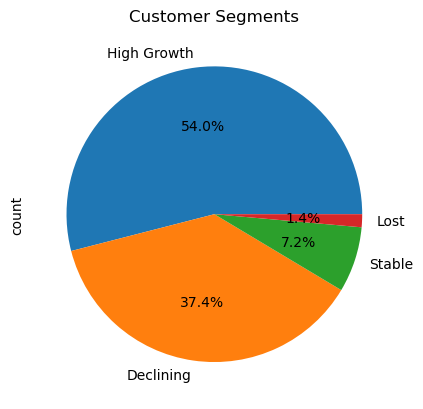

In [35]:
cust['category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Segments")
plt.show()

# Customer Segment Distribution (Bar Chart)

## In this step, a bar chart is created to show the number of customers in each category.

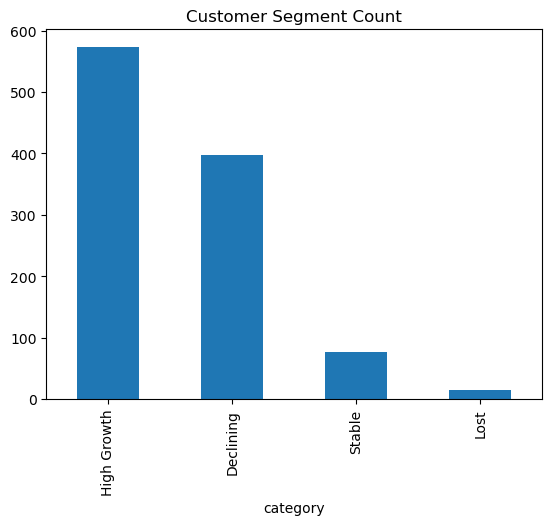

In [36]:
cust['category'].value_counts().plot(kind='bar')
plt.title("Customer Segment Count")
plt.show()

# Revenue Analysis
## Revenue is calculated using a base cost of $22 per parcel to estimate the financial impact of COVID-19.

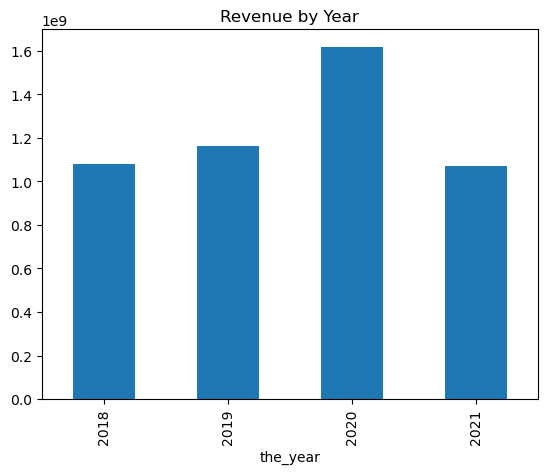

In [58]:
df['revenue'] = df['volume'] * 22

df.groupby('the_year')['revenue'].sum().plot(kind='bar')
plt.title("Revenue by Year")
plt.show()

# Peak Season Analysis
## Peak season performance is compared between 2019 and 2020 to understand how COVID-19 impacted high-demand periods.

In [56]:
peak_2019 = df[(df['the_year'] == 2019) & (df['the_week'] >= 45)]
peak_2020 = df[(df['the_year'] == 2020) & (df['the_week'] >= 45)]

print("2019 Peak:", peak_2019['volume'].sum())
print("2020 Peak:", peak_2020['volume'].sum())

2019 Peak: 12731239
2020 Peak: 16402470
